# Exploratory Data Analysis

## Imports

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px

import numpy as np

import folium
import leafmap.foliumap as leafmap

import cartopy.crs as ccrs
import cartopy.feature as cfeature


ModuleNotFoundError: No module named 'cartopy'

In [ ]:
CP = {
    'red': '#E74C3C',        # A vibrant, slightly muted red
    'blue': '#3498DB',       # A standard, clean blue
    'green': '#2ECC71',      # A fresh, bright green
    'purple': '#9B59B6',     # A soft, appealing purple
    'orange': '#F39C12',     # A warm, inviting orange
    'brown': '#8D6E63',      # A versatile, earthy brown
    'pink': '#EC7063',       # A gentle, slightly coral pink
    'teal': '#1ABC9C',       # A calming, deep teal
    'yellow': '#F4D03F',     # A sunny, soft yellow
    'gray': '#95A5A6'        
}

def cat_barplot(data, x_var, y_var):
    temp = data.groupby(x_var, observed=False)[y_var].sum().reset_index()
    plot = sns.barplot(data=temp, x=x_var, y=y_var,hue=x_var )
    plot.set_title(f"{x_var} vs {y_var}")
    return plot

## Data Preparation

### Load Data

In [ ]:
# DATA_FILE_PATH = "../data/dataset_with_some_5min_walkable_POIs_full.csv"
DATA_FILE_PATH = "../data/full_dataset_w_nearest_dist.csv"

data = pd.read_csv(DATA_FILE_PATH)
data["log_count"] = np.log(data["count"]) # Only for the EDA


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

data['day_of_week_name'] = pd.Categorical.from_codes(
    data['day_of_week'] - 1,  # Subtract 1 for zero-based indexing
    categories=day_order,
    ordered=True  # This ensures Monday to Sunday order
)
 

In [ ]:
data.dtypes

start_station_number                   int64
longitude                            float64
latitude                             float64
cafe_count_5min_walk                   int64
atm_count_5min_walk                    int64
pub_count_5min_walk                    int64
school_count_5min_walk                 int64
university_count_5min_walk             int64
college_count_5min_walk                int64
bank_count_5min_walk                   int64
post_office_count_5min_walk            int64
library_count_5min_walk                int64
cinema_count_5min_walk                 int64
supermarket_count_5min_walk            int64
station_count_5min_walk                int64
platform_count_5min_walk               int64
stop_position_count_5min_walk          int64
railway_station_count_5min_walk        int64
highway_bus_stop_count_5min_walk       int64
s_hour                                 int64
time_of_day                           object
peak_off_peak                          int64
s_date    

### Preview Of the Dataset

In [ ]:
data.head(3)

,start_station_number,longitude,latitude,cafe_count_5min_walk,atm_count_5min_walk,pub_count_5min_walk,school_count_5min_walk,university_count_5min_walk,college_count_5min_walk,bank_count_5min_walk,...,dist_to_nearest_library,dist_to_nearest_cinema,dist_to_nearest_supermarket,dist_to_nearest_station,dist_to_nearest_platform,dist_to_nearest_stop_position,dist_to_nearest_railway_station,dist_to_nearest_bus_stop,log_count,day_of_week_name
0,3429,-0.132102,51.498126,13,0,1,3,0,0,0,...,183.757971,388.274181,1040.659561,297.364197,117.091208,117.091208,297.364197,117.091208,0.000000,Friday
1,3429,-0.132102,51.498126,13,0,1,3,0,0,0,...,183.757971,388.274181,1040.659561,297.364197,117.091208,117.091208,297.364197,117.091208,2.833213,Sunday
2,3429,-0.132102,51.498126,13,0,1,3,0,0,0,...,183.757971,388.274181,1040.659561,297.364197,117.091208,117.091208,297.364197,117.091208,0.000000,Monday


In [ ]:
data.isna().sum()

start_station_number                0
longitude                           0
latitude                            0
cafe_count_5min_walk                0
atm_count_5min_walk                 0
pub_count_5min_walk                 0
school_count_5min_walk              0
university_count_5min_walk          0
college_count_5min_walk             0
bank_count_5min_walk                0
post_office_count_5min_walk         0
library_count_5min_walk             0
cinema_count_5min_walk              0
supermarket_count_5min_walk         0
station_count_5min_walk             0
platform_count_5min_walk            0
stop_position_count_5min_walk       0
railway_station_count_5min_walk     0
highway_bus_stop_count_5min_walk    0
s_hour                              0
time_of_day                         0
peak_off_peak                       0
s_date                              0
week_of_the_month                   0
day_of_week                         0
weekday_or_weekend_sdate            0
count       

### Configuring Data Types

In [ ]:
categorical_col_list = ["peak_off_peak", "s_hour", "day_of_week", "week_of_the_month"]

for col in categorical_col_list:
    data[col] = data[col].astype("object")


In [ ]:
data.dtypes

start_station_number                   int64
longitude                            float64
latitude                             float64
cafe_count_5min_walk                   int64
atm_count_5min_walk                    int64
pub_count_5min_walk                    int64
school_count_5min_walk                 int64
university_count_5min_walk             int64
college_count_5min_walk                int64
bank_count_5min_walk                   int64
post_office_count_5min_walk            int64
library_count_5min_walk                int64
cinema_count_5min_walk                 int64
supermarket_count_5min_walk            int64
station_count_5min_walk                int64
platform_count_5min_walk               int64
stop_position_count_5min_walk          int64
railway_station_count_5min_walk        int64
highway_bus_stop_count_5min_walk       int64
s_hour                                object
time_of_day                           object
peak_off_peak                         object
s_date    

In [ ]:
categorical_cols = list(data.dtypes[data.dtypes == 'object'].index)
categorical_cols
print("Categorical Variables: ")
for col in categorical_cols:
    l = sorted(list(data[col].unique()))
    print(f"\t{col} - {l}")

Categorical Variables: 
	time_of_day - ['Day', 'Evening', 'Morning', 'Night']
	s_date - ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08', '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12', '2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16', '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24', '2023-01-25', '2023-01-26', '2023-01-27', '2023-01-28', '2023-01-29', '2023-01-30', '2023-01-31']
	weekday_or_weekend_sdate - ['Weekday', 'Weekend']


In [ ]:
numerical_cols = list(data.dtypes[data.dtypes != 'object'].index)
numerical_cols

['start_station_number',
 'longitude',
 'latitude',
 'cafe_count_5min_walk',
 'atm_count_5min_walk',
 'pub_count_5min_walk',
 'school_count_5min_walk',
 'university_count_5min_walk',
 'college_count_5min_walk',
 'bank_count_5min_walk',
 'post_office_count_5min_walk',
 'library_count_5min_walk',
 'cinema_count_5min_walk',
 'supermarket_count_5min_walk',
 'station_count_5min_walk',
 'platform_count_5min_walk',
 'stop_position_count_5min_walk',
 'railway_station_count_5min_walk',
 'highway_bus_stop_count_5min_walk',
 's_hour',
 'peak_off_peak',
 'week_of_the_month',
 'day_of_week',
 'count',
 'dist_to_nearest_cafe',
 'dist_to_nearest_atm',
 'dist_to_nearest_pub',
 'dist_to_nearest_school',
 'dist_to_nearest_university',
 'dist_to_nearest_college',
 'dist_to_nearest_bank',
 'dist_to_nearest_post_office',
 'dist_to_nearest_library',
 'dist_to_nearest_cinema',
 'dist_to_nearest_supermarket',
 'dist_to_nearest_station',
 'dist_to_nearest_platform',
 'dist_to_nearest_stop_position',
 'dist_to_

In [ ]:
num = 1

print("All Column Names: ")
for column in data.columns:
    print(f"\t{num}) " + column)
    num += 1

All Column Names: 
	1) start_station_number
	2) longitude
	3) latitude
	4) cafe_count_5min_walk
	5) atm_count_5min_walk
	6) pub_count_5min_walk
	7) school_count_5min_walk
	8) university_count_5min_walk
	9) college_count_5min_walk
	10) bank_count_5min_walk
	11) post_office_count_5min_walk
	12) library_count_5min_walk
	13) cinema_count_5min_walk
	14) supermarket_count_5min_walk
	15) station_count_5min_walk
	16) platform_count_5min_walk
	17) stop_position_count_5min_walk
	18) railway_station_count_5min_walk
	19) highway_bus_stop_count_5min_walk
	20) s_hour
	21) time_of_day
	22) peak_off_peak
	23) s_date
	24) week_of_the_month
	25) day_of_week
	26) weekday_or_weekend_sdate
	27) count
	28) dist_to_nearest_cafe
	29) dist_to_nearest_atm
	30) dist_to_nearest_pub
	31) dist_to_nearest_school
	32) dist_to_nearest_university
	33) dist_to_nearest_college
	34) dist_to_nearest_bank
	35) dist_to_nearest_post_office
	36) dist_to_nearest_library
	37) dist_to_nearest_cinema
	38) dist_to_nearest_supermark

## Descriptive Analysis

In [ ]:
data[numerical_cols].describe()

,start_station_number,longitude,latitude,cafe_count_5min_walk,atm_count_5min_walk,pub_count_5min_walk,school_count_5min_walk,university_count_5min_walk,college_count_5min_walk,bank_count_5min_walk,...,dist_to_nearest_post_office,dist_to_nearest_library,dist_to_nearest_cinema,dist_to_nearest_supermarket,dist_to_nearest_station,dist_to_nearest_platform,dist_to_nearest_stop_position,dist_to_nearest_railway_station,dist_to_nearest_bus_stop,log_count
count,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000,...,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000,244069.000000
mean,110977.059573,-0.127388,51.506242,5.519427,1.495573,1.192208,0.087856,0.177982,0.097276,0.455076,...,543.135270,715.867458,981.585383,534.825078,498.664963,122.539078,219.812398,503.435825,130.301263,0.574332
std,122002.370007,0.052902,0.019710,5.644802,1.863916,1.514427,0.328133,1.315626,0.383707,0.990123,...,377.515732,477.901223,704.980343,535.864360,358.552522,114.328402,412.808881,354.710886,121.064322,0.643107
min,959.000000,-0.236770,51.454753,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1150.000000,-0.170211,51.493072,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,275.246833,387.289152,488.658737,227.591999,237.934831,37.131781,55.098867,248.362702,40.314627,0.000000
50%,3504.000000,-0.127554,51.509303,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,495.044742,632.113091,817.564575,435.265159,435.238441,86.969711,129.312318,445.774416,93.307101,0.693147
75%,200193.000000,-0.089888,51.521114,8.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,714.485516,936.626962,1295.131139,716.766097,660.578997,192.803463,257.674422,666.214701,199.770973,1.098612
max,300253.000000,-0.002275,51.549369,32.000000,11.000000,8.000000,3.000000,20.000000,3.000000,6.000000,...,2712.114553,2761.968516,5587.024819,5655.860660,2274.666223,566.206077,5996.083083,1923.053382,704.435446,4.875197


## Target Variable Analysis

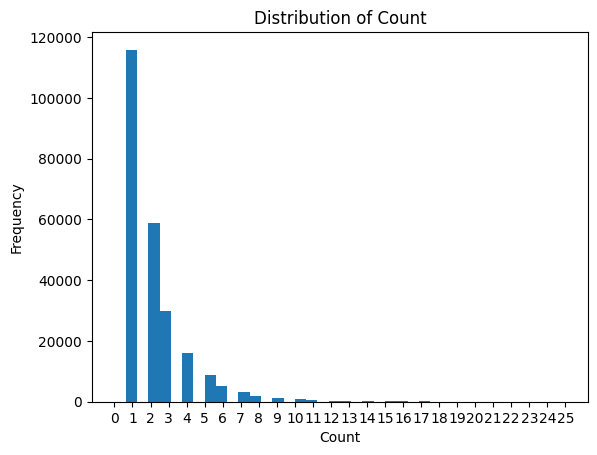

In [ ]:

plt.hist(x = data["count"], bins=40, range=[0, 25])
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.title("Distribution of Count")
plt.xticks(range(26))

plt.show()

## Start Date

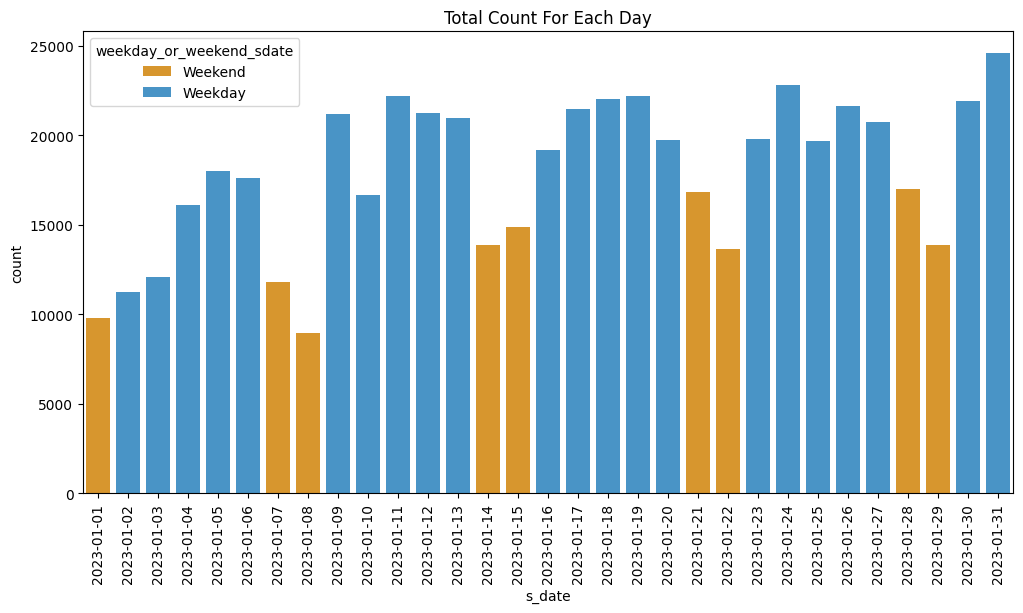

In [ ]:
agg_dict = {"weekday_or_weekend_sdate":"first",
            "count":"sum"
}

temp = data.groupby("s_date").agg(agg_dict).reset_index()

plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x="s_date", y="count",hue="weekday_or_weekend_sdate", palette=[CP["orange"],CP["blue"]], data=temp)
bar_plot.tick_params(axis="x",rotation=90)
plt.title("Total Count For Each Day")
plt.show()

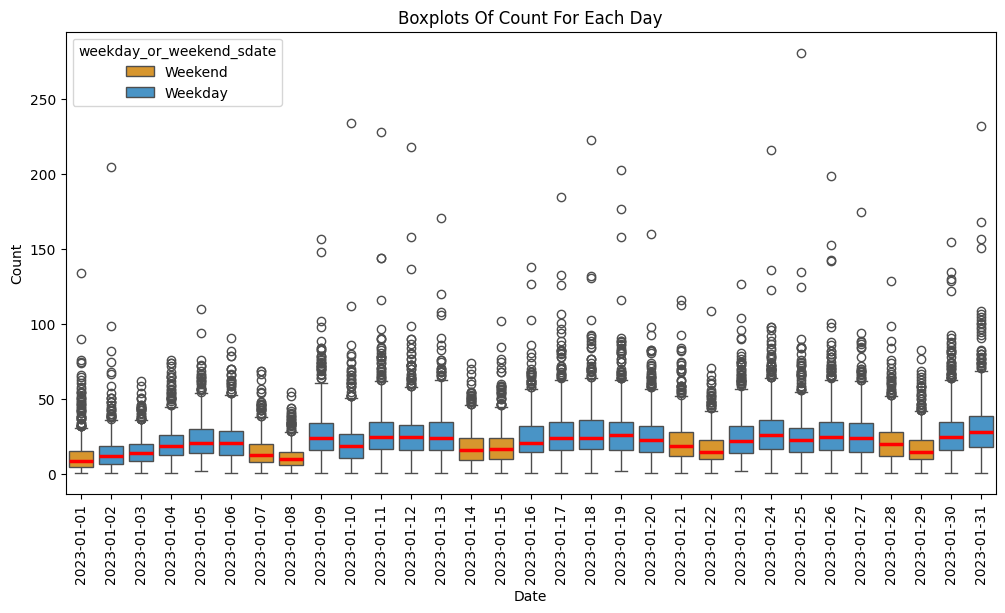

In [ ]:
temp = data[["count", "s_date", "weekday_or_weekend_sdate", "start_station_number"]].sort_values("s_date")

temp = temp.groupby(["start_station_number", "s_date", "weekday_or_weekend_sdate"])["count"].sum().reset_index()

plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=temp, y="count", x="s_date", hue="weekday_or_weekend_sdate", palette=[CP["orange"],CP["blue"]], medianprops={'color': 'red', 'linewidth': 2.5, 'linestyle': '-'})
overall_median_count = temp['count'].median()
box_plot.tick_params(axis="x",rotation=90)
plt.title("Boxplots Of Count For Each Day")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()

Note
> - Each Boxplot is made of 784 records (Number of stations)
> - It is clear that the weekends of each week has relatively lower demand than the weekdays

## Start Hour

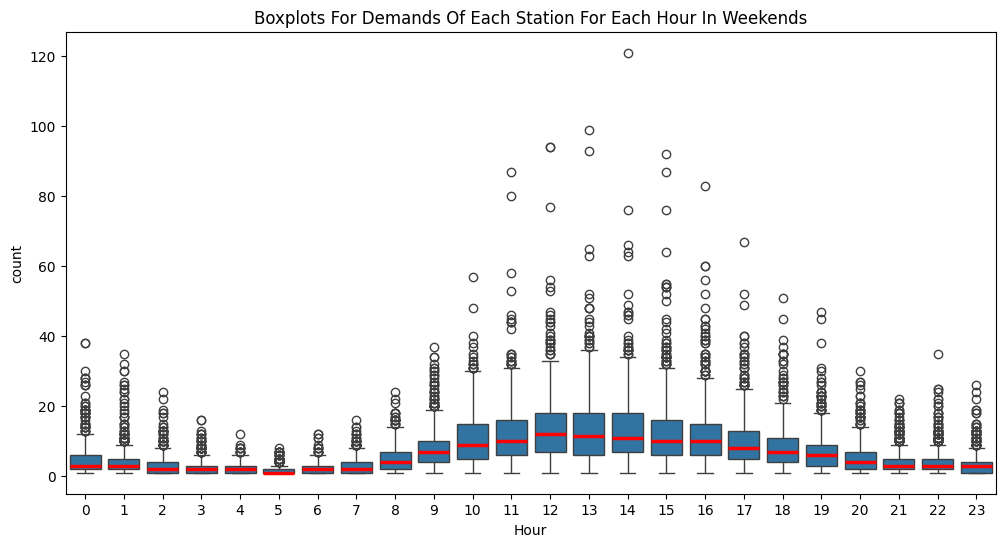

In [ ]:
temp = data.groupby(["s_hour","start_station_number", "weekday_or_weekend_sdate"], observed=False)["count"].sum().reset_index()

plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=temp[temp["weekday_or_weekend_sdate"] == "Weekend"], y="count", x="s_hour", medianprops={'color': 'red', 'linewidth': 2.5, 'linestyle': '-'})
overall_median_count = temp['count'].median()
plt.title("Boxplots for demands of each station for each hour in weekends".title())
plt.xlabel("Hour")
plt.show()

Note
> It is clear that in weekends the stations have a relatively higher demand from around 10 am to 5 pm

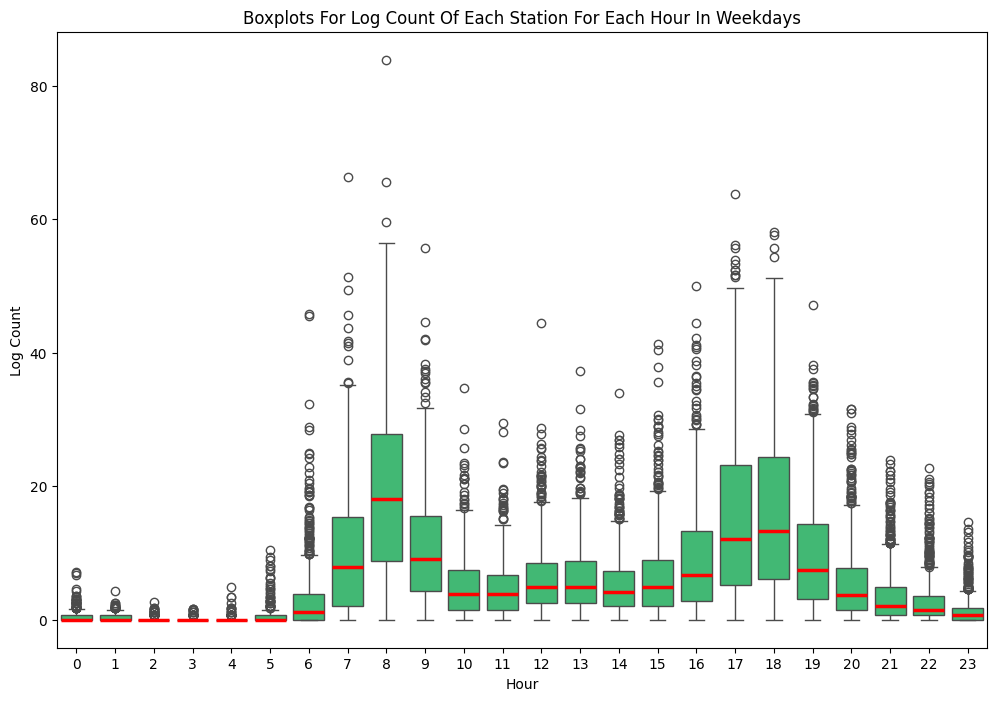

In [ ]:
temp = data.groupby(["s_hour","start_station_number", "weekday_or_weekend_sdate"], observed=False)["log_count"].sum().reset_index()

plt.figure(figsize=(12, 8))
box_plot = sns.boxplot(data=temp[temp["weekday_or_weekend_sdate"] == "Weekday"], y="log_count", x="s_hour",color=CP["green"], medianprops={'color': 'red', 'linewidth': 2.5, 'linestyle': '-'})
overall_median_count = temp['log_count'].median()
plt.title("Boxplots for Log Count of each station for each hour in weekdays".title())
plt.xlabel("Hour")
plt.ylabel("Log Count")
plt.show()

> Note that there are 2 peaks in the demand in stations for weekdays at around 7 a.m to 9 a.m and 5 p.m. to 7 p.m

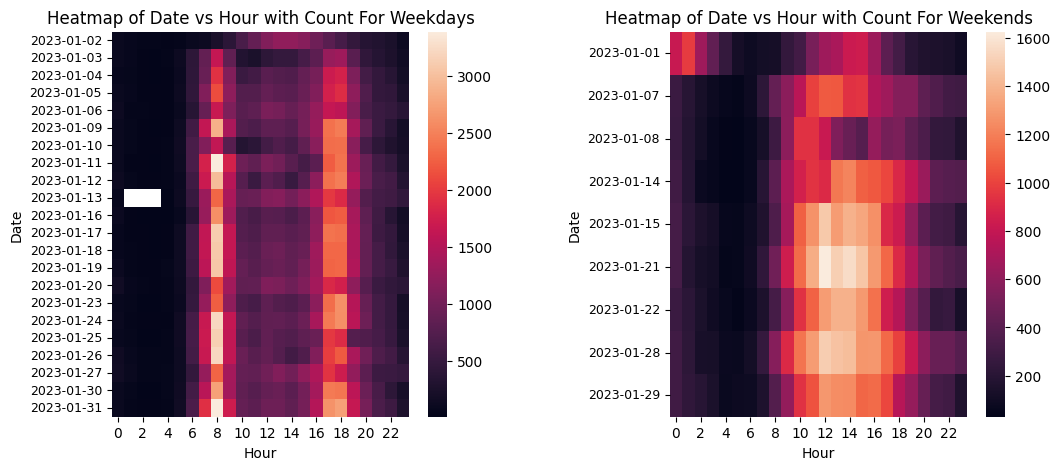

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

temp = data[data["weekday_or_weekend_sdate"] == "Weekday"].groupby(["s_hour","s_date"], observed=False)["count"].sum().reset_index()
pivot_table = temp.pivot(index="s_date", columns="s_hour", values="count")
sns.heatmap(pivot_table, ax=ax[0])
ax[0].tick_params(axis='y', labelsize=9)
ax[0].set_ylabel("Date")
ax[0].set_xlabel("Hour")
ax[0].set_title("Heatmap of Date vs Hour with Count For Weekdays")

temp = data[data["weekday_or_weekend_sdate"] == "Weekend"].groupby(["s_hour","s_date"], observed=False)["count"].sum().reset_index()
pivot_table = temp.pivot(index="s_date", columns="s_hour", values="count")
sns.heatmap(pivot_table, ax=ax[1])
ax[1].tick_params(axis='y', labelsize=9)
ax[1].set_ylabel("Date")
ax[1].set_xlabel("Hour")
ax[1].set_title("Heatmap of Date vs Hour with Count For Weekends")

plt.subplots_adjust(
    wspace=0.5,  
    hspace=0.6  
)

plt.show()


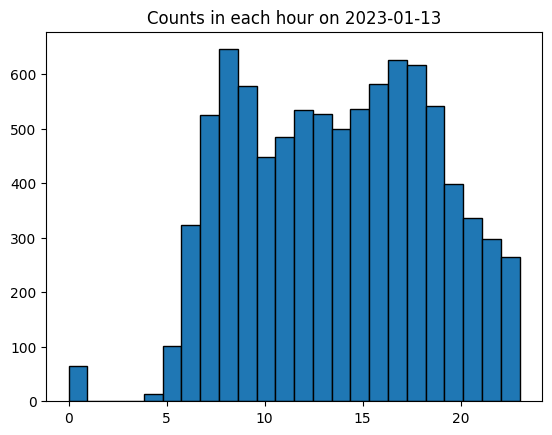

In [ ]:
temp = data[data["s_date"] == "2023-01-13"]

plt.hist(data=temp, x="s_hour", bins=24, edgecolor="black")
plt.title("Counts in each hour on 2023-01-13")
plt.show()


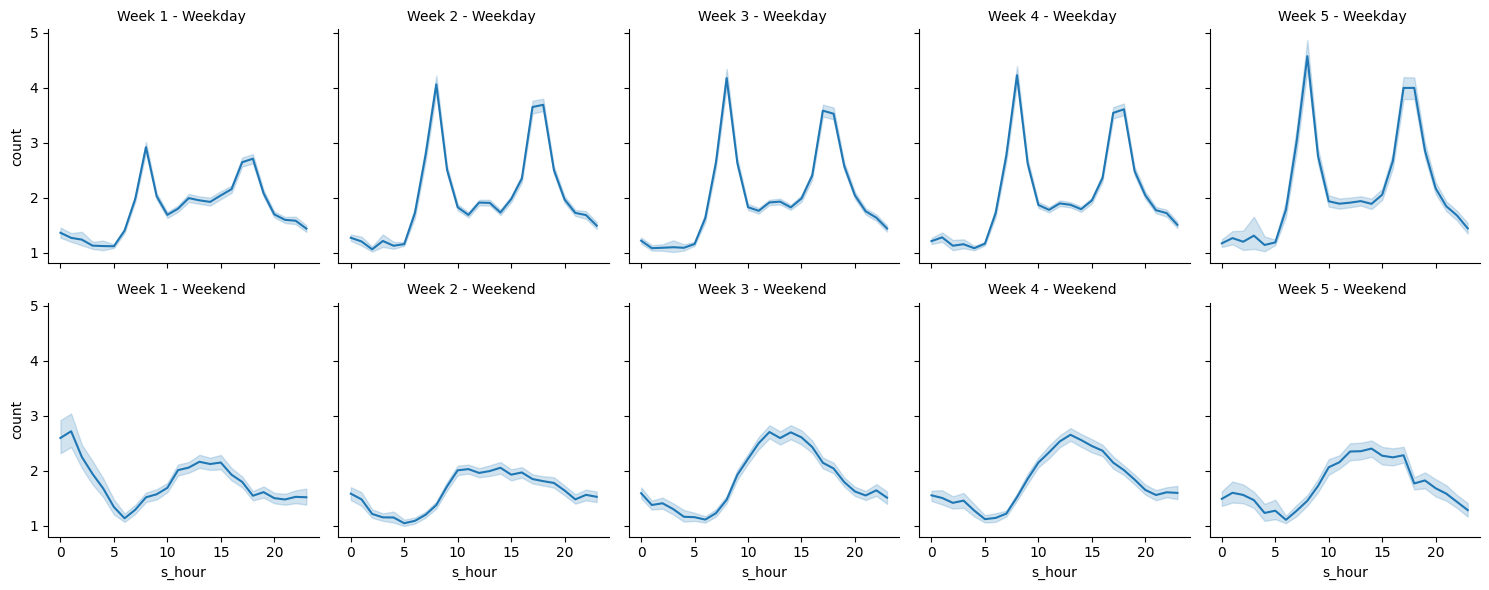

In [ ]:
grid = sns.FacetGrid(data, col='week_of_the_month' ,row="weekday_or_weekend_sdate").map(sns.lineplot, 's_hour', 'count')
grid.set_titles("Week {col_name} - {row_name} ")
plt.show()

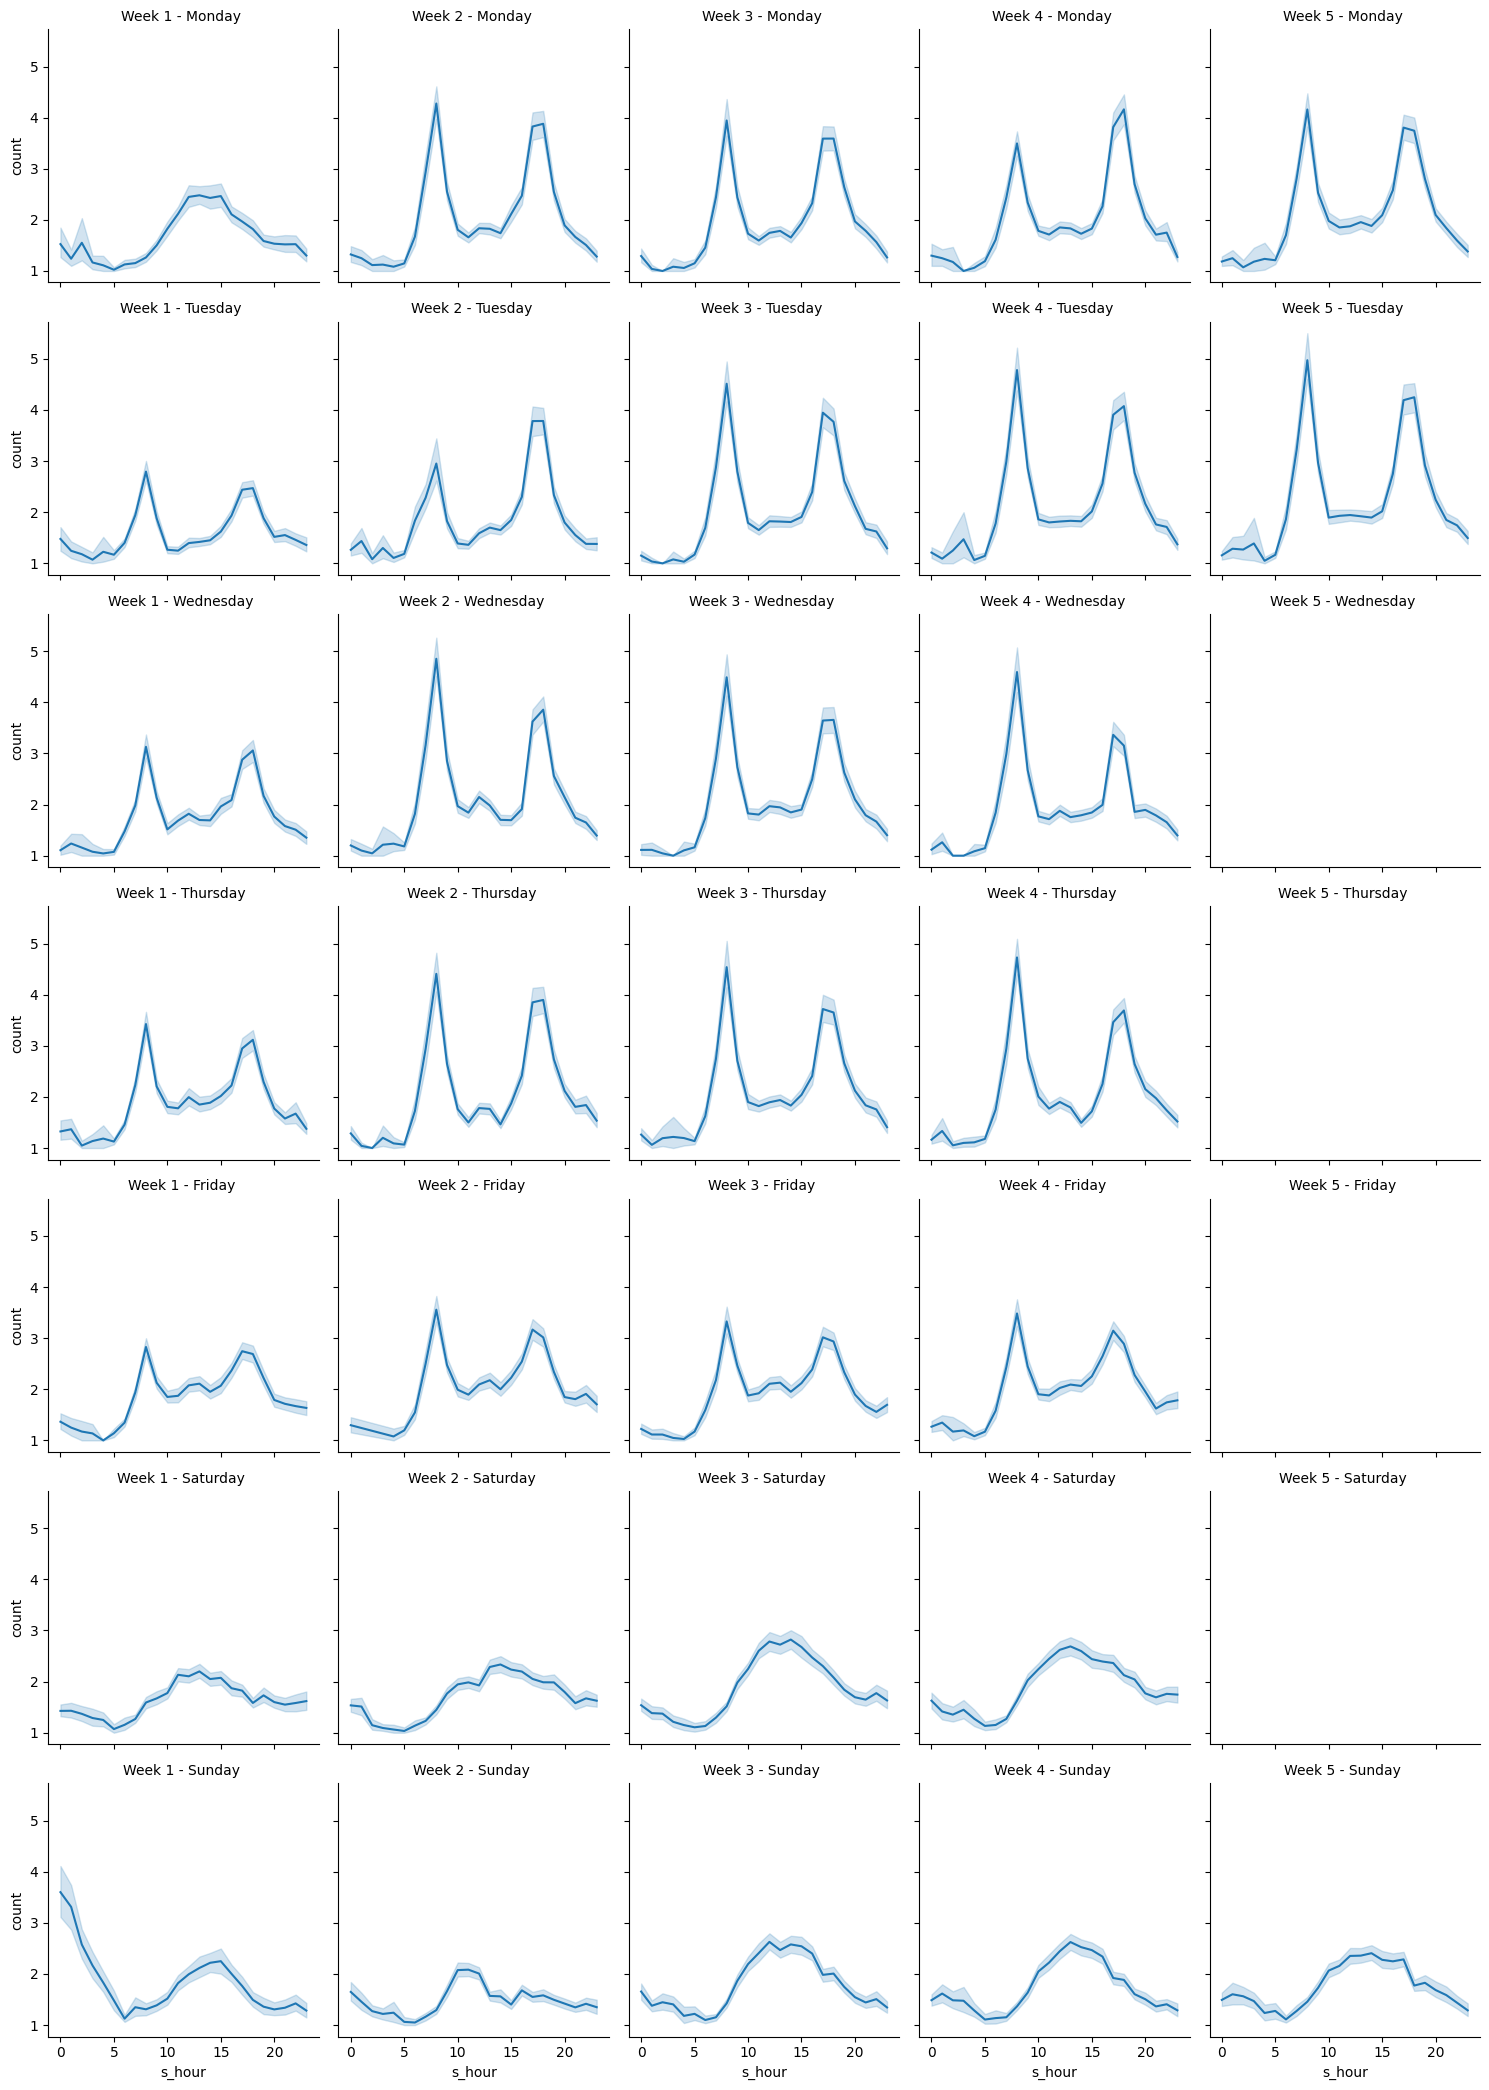

In [ ]:

grid = sns.FacetGrid(data, col='week_of_the_month' ,row="day_of_week_name").map(sns.lineplot, 's_hour', 'count')
grid.set_titles("Week {col_name} - {row_name} ")

plt.savefig("graph.png", dpi=300, bbox_inches='tight')
plt.show()

> With that information a new feature ( peak_off_peak ) with following criteria was formed
> - For Weekdays if the start hour is between 7-9 and 17-19 it is cosidered as a peak hour else it is a off-peak hour
> - For Weekends if the start hour is between 10-17 it is considered as a peak hour else it is a off peak hour

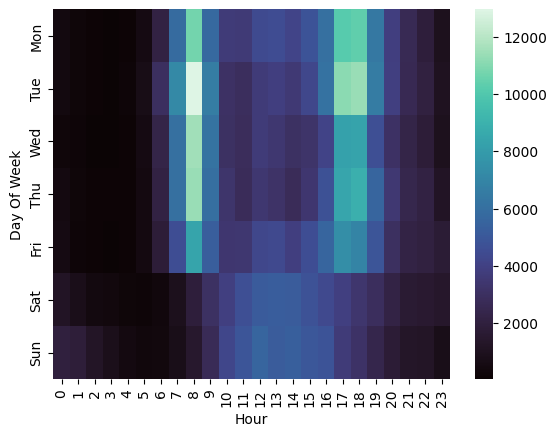

In [ ]:


temp = data.groupby(["s_hour","day_of_week"], observed=False)["count"].sum().reset_index()
pivot_table = temp.pivot(index="day_of_week", columns="s_hour", values="count")
plot = sns.heatmap(pivot_table, cmap="mako")
plot.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plot.set_ylabel("Day Of Week")
plot.set_xlabel("Hour")
plt.show()

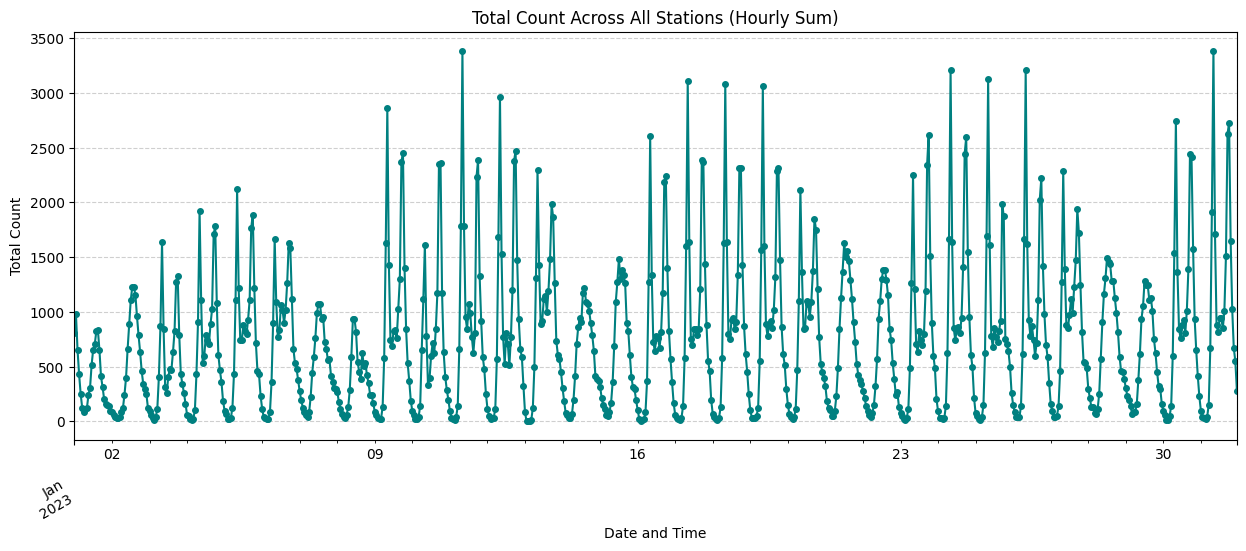

In [ ]:
temp = data
temp['Datetime'] = pd.to_datetime(data['s_date']) + pd.to_timedelta(data['s_hour'], unit='H')

temp = temp.set_index("Datetime")
hourly_totals = temp['count'].resample('H').sum()
plt.figure(figsize=(15, 6))
hourly_totals.plot(kind='line', marker='o', linestyle='-', color='teal', markersize=4)
plt.title('Total Count Across All Stations (Hourly Sum)')
plt.xlabel('Date and Time')
plt.ylabel('Total Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.gcf().autofmt_xdate() # Formats x-axis dates nicely
plt.show()


## Peak Hours / Off Peak Hours

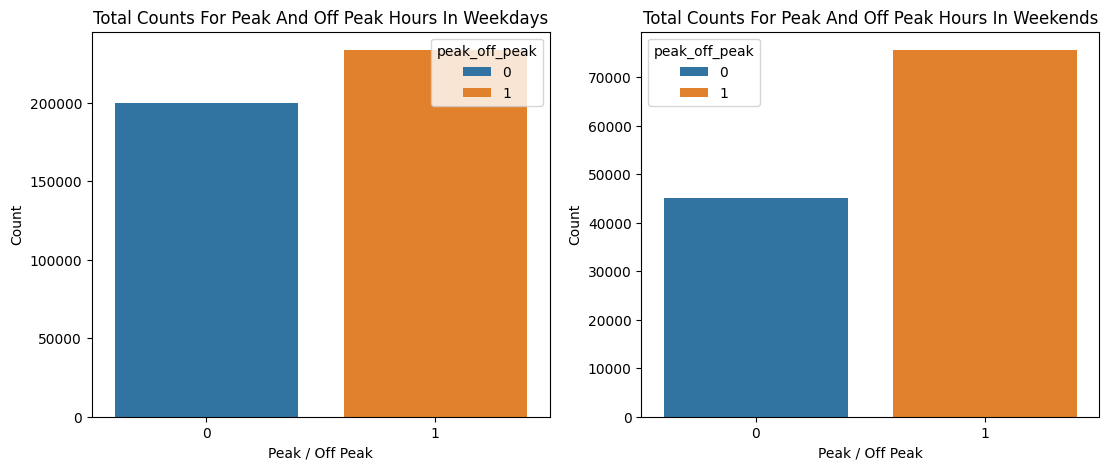

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13,5))

temp = data[data["weekday_or_weekend_sdate"] == "Weekend"]
temp = temp.groupby( ["peak_off_peak"],observed=False)["count"].sum().reset_index()
plot = sns.barplot(data=temp, x="peak_off_peak", y="count", hue="peak_off_peak", ax=ax[1])


temp = data[data["weekday_or_weekend_sdate"] == "Weekday"]
temp = temp.groupby( ["peak_off_peak"],observed=False)["count"].sum().reset_index()
plot = sns.barplot(data=temp, x="peak_off_peak", y="count", hue="peak_off_peak", ax=ax[0])

ax[0].set_title("Total counts for peak and off peak hours in Weekdays".title())
ax[0].set_xlabel("Peak / Off Peak")
ax[0].set_ylabel("Count")

ax[1].set_title("Total counts for peak and off peak hours in Weekends".title())
ax[1].set_xlabel("Peak / Off Peak")
ax[1].set_ylabel("Count")



plt.show()

### Peak Off Peak With Start Date

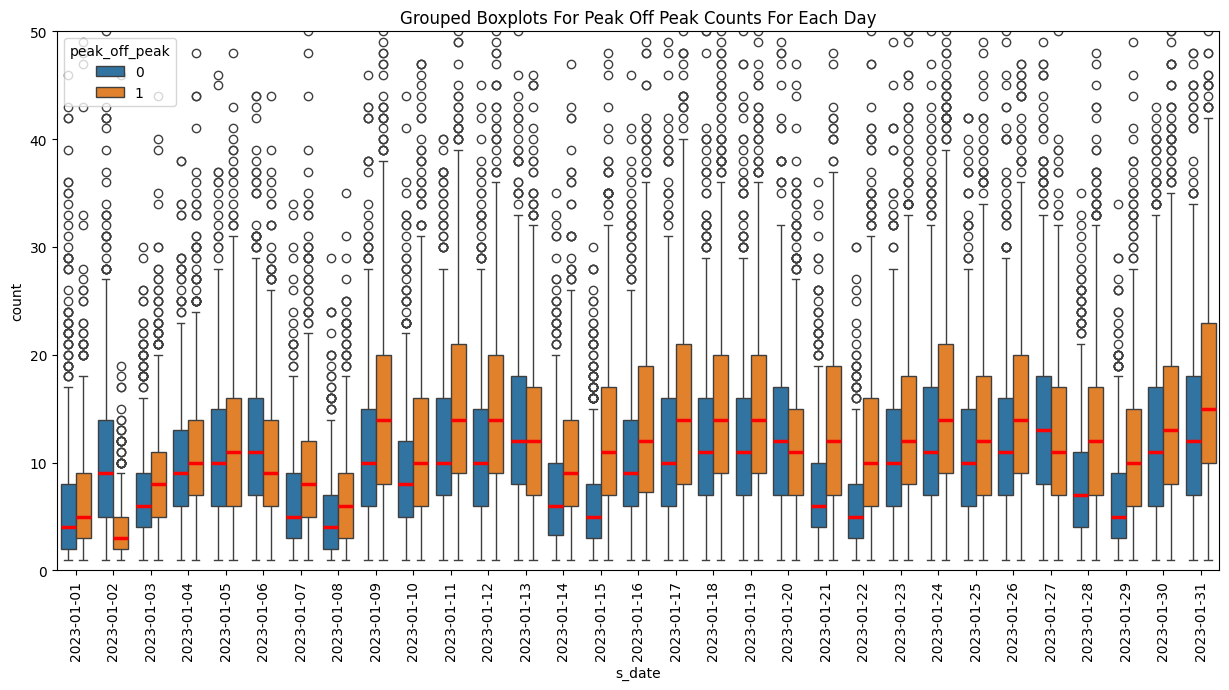

In [ ]:
plt.figure(figsize=(15, 7))

temp = data.groupby(["s_date","start_station_number", "peak_off_peak"], observed=False)["count"].sum().reset_index()

box_plot = sns.boxplot(data=temp ,y="count", x="s_date", hue="peak_off_peak", medianprops={'color': 'red', 'linewidth': 2.5, 'linestyle': '-'})
box_plot.tick_params(axis="x",rotation=90)
plt.title("Grouped BoxPlots for Peak Off Peak Counts for each day".title())
plt.ylim(0,50)
plt.show()

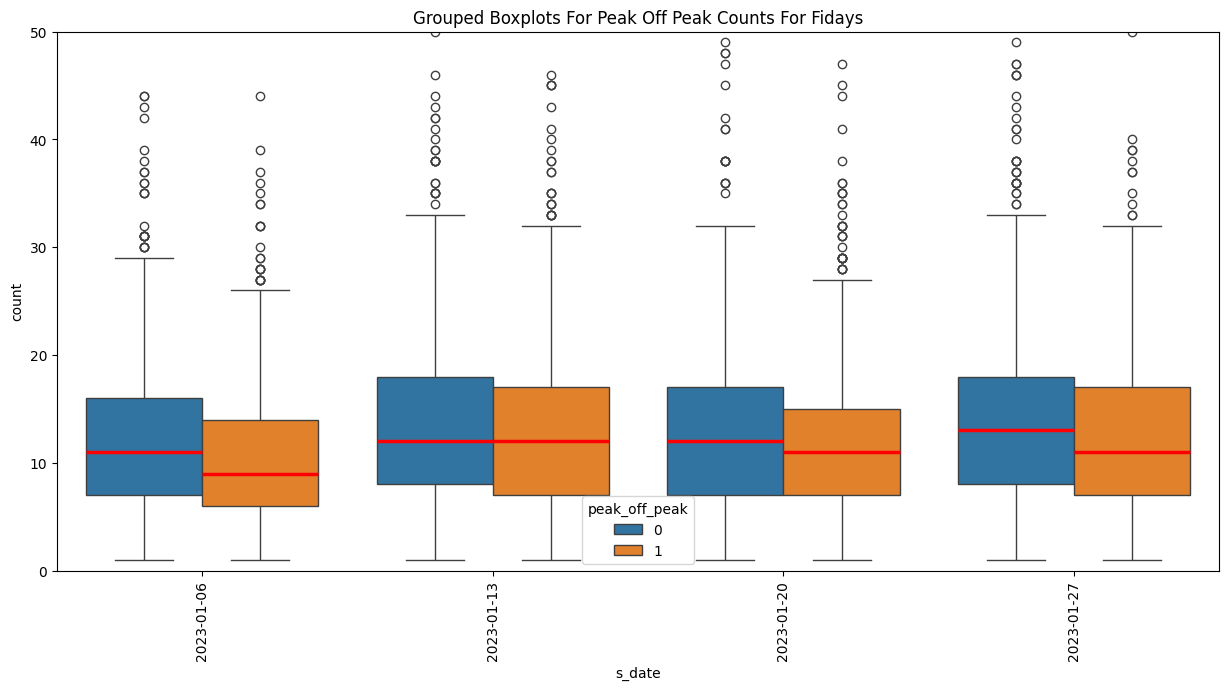

In [ ]:
plt.figure(figsize=(15, 7))

temp = data[data["day_of_week"] == 5].groupby(["s_date","start_station_number", "peak_off_peak"], observed=False)["count"].sum().reset_index()

box_plot = sns.boxplot(data=temp ,y="count", x="s_date", hue="peak_off_peak", medianprops={'color': 'red', 'linewidth': 2.5, 'linestyle': '-'})
box_plot.tick_params(axis="x",rotation=90)
plt.title("Grouped BoxPlots for Peak Off Peak Counts for Fidays".title())
plt.ylim(0,50)
plt.show()


> For Every Friday the off peak demand is greater than the peak demand

### Time of the day With Start Date

> Time of the day cluster criteria:
> - Morning Hours -> 6 to 11
> - Day - > 12 to 17
> - Evening -> 18 to 21
> - Night -> 0 to 5 and 22 to 23

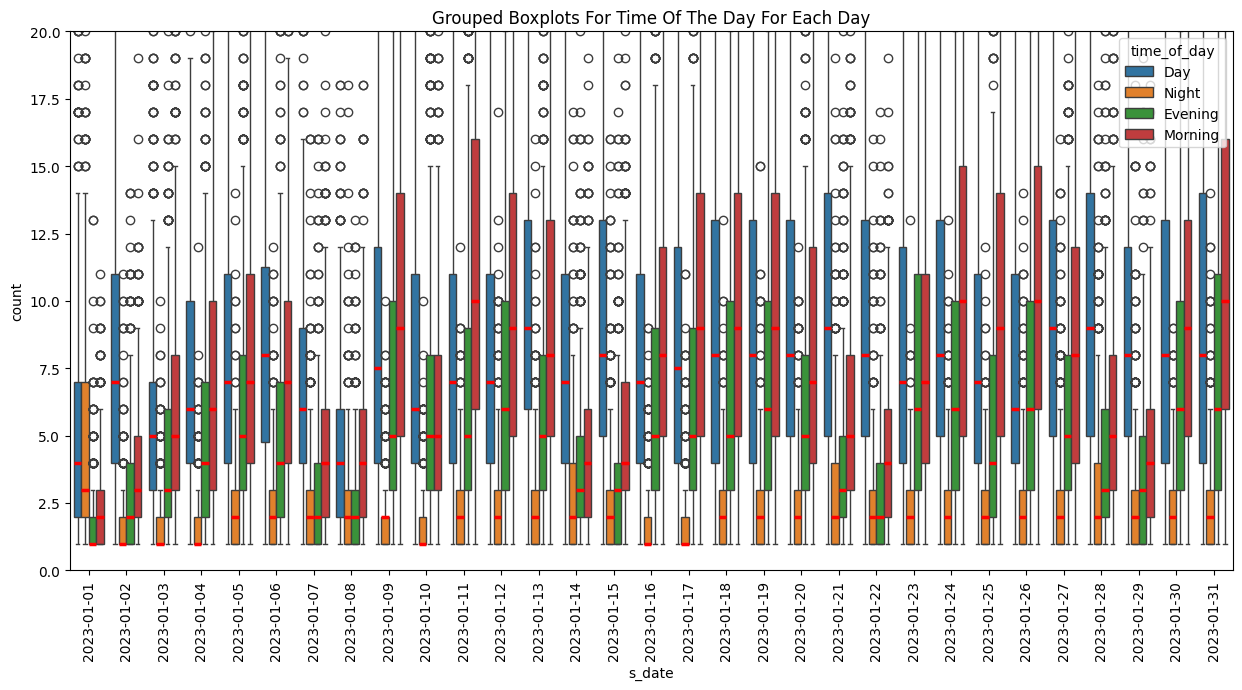

In [ ]:
plt.figure(figsize=(15, 7))

temp = data.groupby(["s_date","start_station_number", "time_of_day"], observed=False)["count"].sum().reset_index()

box_plot = sns.boxplot(data=temp ,y="count", x="s_date", hue="time_of_day", medianprops={'color': 'red', 'linewidth': 2.5, 'linestyle': '-'})
box_plot.tick_params(axis="x",rotation=90)
plt.title("Grouped BoxPlots for Time of the Day for each day".title())
plt.ylim(0,20)
plt.show()

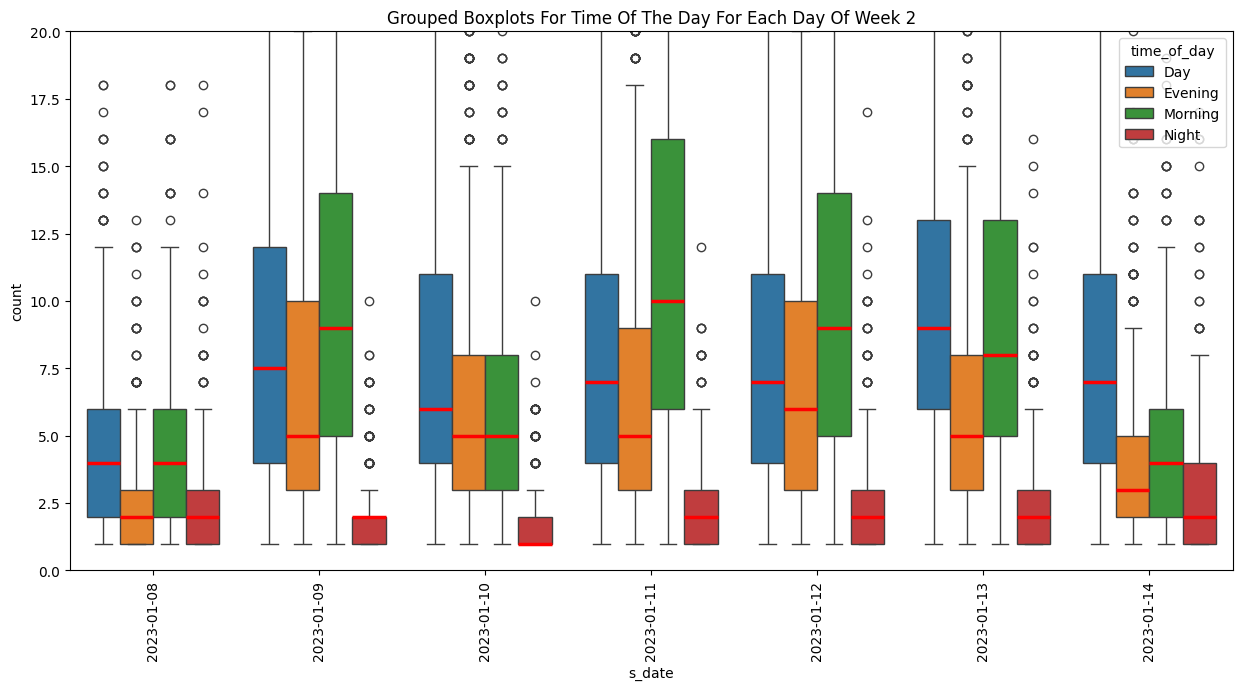

In [ ]:
plt.figure(figsize=(15, 7))

temp = data[data["week_of_the_month"] == 2].groupby(["s_date","start_station_number", "time_of_day"], observed=False)["count"].sum().reset_index()

box_plot = sns.boxplot(data=temp ,y="count", x="s_date", hue="time_of_day", medianprops={'color': 'red', 'linewidth': 2.5, 'linestyle': '-'})
box_plot.tick_params(axis="x",rotation=90)
plt.title("Grouped BoxPlots for Time of the Day for each day of Week 2".title())
plt.ylim(0,20)
plt.show()

### Demands for each week of the month 

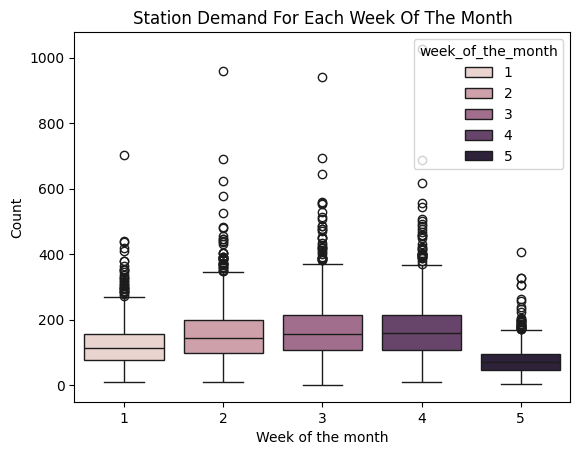

In [ ]:


temp = data.groupby(["week_of_the_month", "start_station_number"],observed=False)["count"].sum().reset_index()
plot = sns.boxplot(data=temp, x="week_of_the_month", y="count", hue="week_of_the_month")

plt.title("station demand for each week of the month".title())
plt.xlabel("Week of the month")
plt.ylabel("Count")
plt.show()


## Numerical Feature Analysis


In [ ]:
numerical_cols

['start_station_number',
 'longitude',
 'latitude',
 'cafe_count_5min_walk',
 'atm_count_5min_walk',
 'pub_count_5min_walk',
 'school_count_5min_walk',
 'university_count_5min_walk',
 'college_count_5min_walk',
 'bank_count_5min_walk',
 'post_office_count_5min_walk',
 'library_count_5min_walk',
 'cinema_count_5min_walk',
 'supermarket_count_5min_walk',
 'station_count_5min_walk',
 'platform_count_5min_walk',
 'stop_position_count_5min_walk',
 'railway_station_count_5min_walk',
 'highway_bus_stop_count_5min_walk',
 'count',
 'dist_to_nearest_cafe',
 'dist_to_nearest_atm',
 'dist_to_nearest_pub',
 'dist_to_nearest_school',
 'dist_to_nearest_university',
 'dist_to_nearest_college',
 'dist_to_nearest_bank',
 'dist_to_nearest_post_office',
 'dist_to_nearest_library',
 'dist_to_nearest_cinema',
 'dist_to_nearest_supermarket',
 'dist_to_nearest_station',
 'dist_to_nearest_platform',
 'dist_to_nearest_stop_position',
 'dist_to_nearest_railway_station',
 'dist_to_nearest_bus_stop',
 'log_count'

### Distributions of Amenities

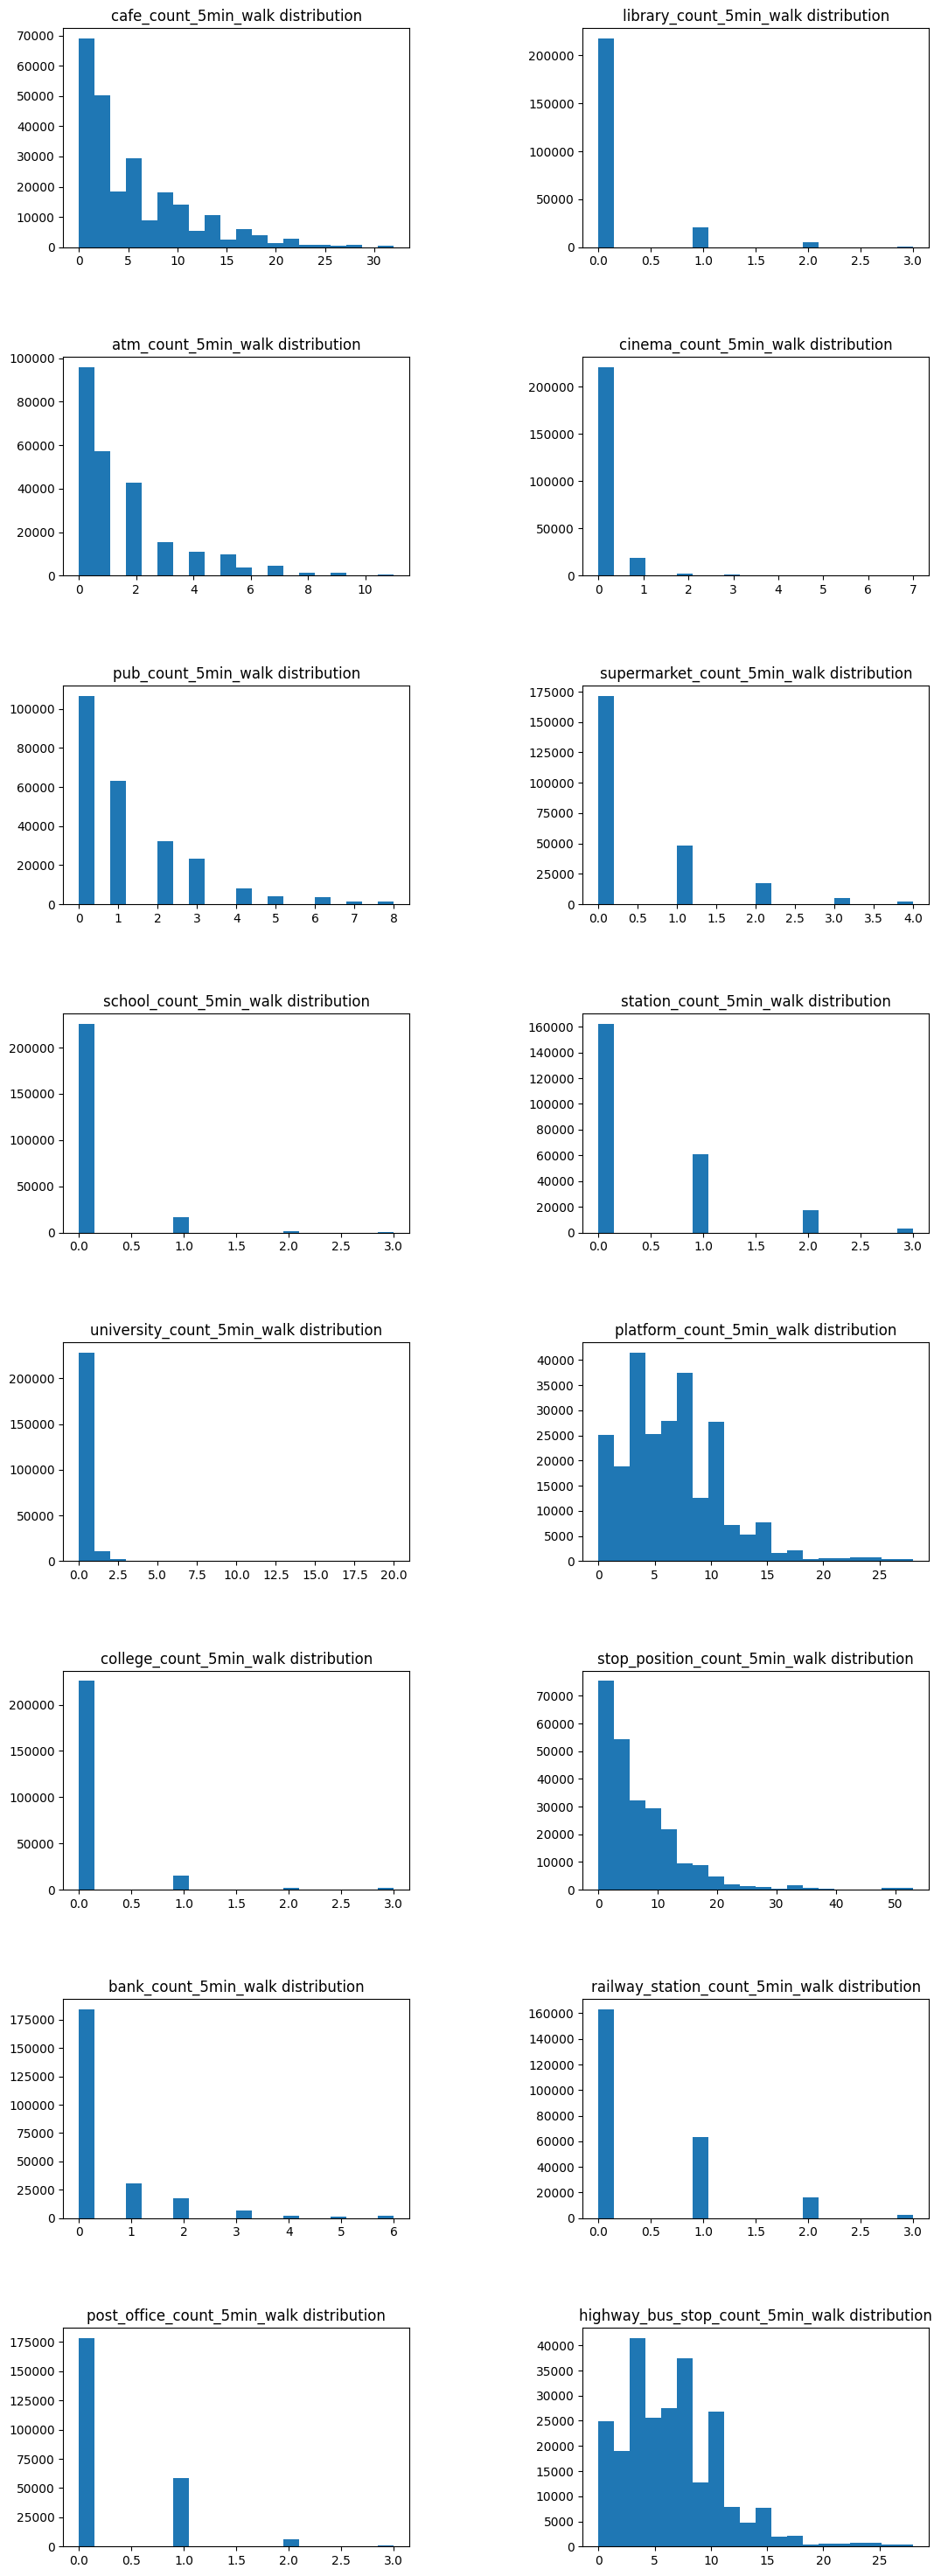

In [ ]:
amenity_list = [col for col in numerical_cols if "walk" in col]

n_rows = int(len(amenity_list)/2)

figure, axis = plt.subplots(n_rows, 2, figsize=(11, 4*n_rows))
index = 0

for col in range(2):
    for row in range(n_rows):


        axis[row, col].hist(data[amenity_list[index]], bins=20)
        axis[row, col].set_title(f"{amenity_list[index]} distribution")
        index += 1

plt.subplots_adjust(
    left=0.1,    # The left side of the subplots of the figure
    right=1,   # The right side of the subplots of the figure
    bottom=0.1,  # The bottom of the subplots of the figure
    top=1,     # The top of the subplots of the figure
    wspace=0.5,  # The amount of width reserved for blank space between subplots
    hspace=0.5   # The amount of height reserved for white space between subplots
)

plt.show()

## Distribution of stations on a map

In [ ]:
london_lat, london_lon = 51.5094, -0.1357

temp = data.groupby(["start_station_number", "latitude", "longitude"])["count"].sum().reset_index()

m = leafmap.Map(location=[london_lat, london_lon], zoom_start=12,tiles="Cartodb Positron")
m.add_basemap("ROADMAP")

for index, row in temp.iterrows():

    circle = folium.CircleMarker(
        [row["latitude"],
        row["longitude"]],
        tooltip=f"{row["start_station_number"]}",
        radius=2, 
        color="red",  
        fill=True,  
        fill_opacity=1
        ).add_to(m)
    
m

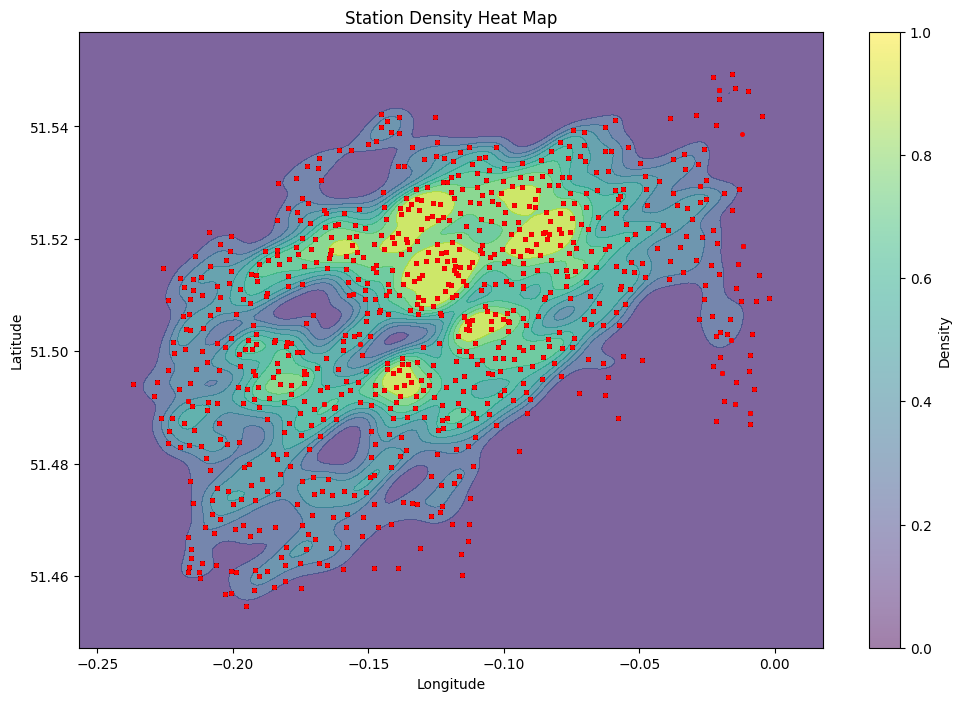

In [ ]:
# Create the plot
plt.figure(figsize=(12, 8))


df = data
# Create a 2D density plot (heatmap)
sns.kdeplot(
    x=df['longitude'],
    y=df['latitude'],
    cmap='viridis',  # Color scheme
    fill=True,      # Fill contours
    thresh=0,       # Show all contours
    alpha=0.7       # Transparency
)

# Add station points
plt.scatter(
    x=df['longitude'],
    y=df['latitude'],
    color='red',
    s=5,            # Point size
    alpha=0.5       # Transparency
)

# Add labels and title
plt.title('Station Density Heat Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Density')

plt.show()